In [1]:
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    hamming_loss,
    classification_report,
    multilabel_confusion_matrix
)

from model import TimeSeriesMultiLabelDataset, CNNBiLSTMMultiLabelClassifier

In [2]:
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

OUTPUT_DIR = Path("mmi711_outputs_multilabel")
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
data = np.load(OUTPUT_DIR / "mmi711_multilabel_variable_length_datasets.npz")

with open(OUTPUT_DIR / "dataset_config_multilabel_variable_lengths.json", "r") as f:
    config = json.load(f)

LENGTHS = config["lengths"]
EVENT_LABELS = config["event_labels"]
EVENT_TO_ID = config["event_to_id"]
ID_TO_EVENT = {int(v): k for k, v in EVENT_TO_ID.items()}

meta_all = pd.read_csv(OUTPUT_DIR / "meta_all_multilabel_variable_lengths.csv")

print("Lengths:", LENGTHS)
print("Event labels:", EVENT_LABELS)
print("Metadata shape:", meta_all.shape)
print(meta_all[["dataset", "length", "scenario", "scenario_group", "background"]].head())

Lengths: [400, 800, 1200]
Event labels: ['mean_shift', 'variance_shift', 'trend_shift', 'point_anomaly', 'collective_anomaly']
Metadata shape: (4560, 11)
  dataset  length                        scenario scenario_group  \
0   train     400                        no_event       no_event   
1   train     400                     trend_shift   single_event   
2   train     400  trend_shift+collective_anomaly  shift_anomaly   
3   train     400  trend_shift+collective_anomaly  shift_anomaly   
4   train     400        mean_shift+point_anomaly  shift_anomaly   

                  background  
0            quadratic_trend  
1  single_seasonality+linear  
2                     linear  
3  single_seasonality+linear  
4         single_seasonality  


In [4]:
X_train_by_length = {}
Y_train_by_length = {}

X_val_by_length = {}
Y_val_by_length = {}

X_ood_params_by_length = {}
Y_ood_params_by_length = {}

X_ood_background_by_length = {}
Y_ood_background_by_length = {}

for length in LENGTHS:
    X_train_by_length[length] = data[f"X_train_L{length}"]
    Y_train_by_length[length] = data[f"Y_train_L{length}"]

    X_val_by_length[length] = data[f"X_val_L{length}"]
    Y_val_by_length[length] = data[f"Y_val_L{length}"]

    X_ood_params_by_length[length] = data[f"X_ood_params_L{length}"]
    Y_ood_params_by_length[length] = data[f"Y_ood_params_L{length}"]

    X_ood_background_by_length[length] = data[f"X_ood_background_L{length}"]
    Y_ood_background_by_length[length] = data[f"Y_ood_background_L{length}"]

    print(
        f"Length {length}:",
        "train", X_train_by_length[length].shape, Y_train_by_length[length].shape,
        "| val", X_val_by_length[length].shape, Y_val_by_length[length].shape,
        "| ood_params", X_ood_params_by_length[length].shape, Y_ood_params_by_length[length].shape,
        "| ood_background", X_ood_background_by_length[length].shape, Y_ood_background_by_length[length].shape
    )

Length 400: train (800, 400) (800, 5) | val (240, 400) (240, 5) | ood_params (240, 400) (240, 5) | ood_background (240, 400) (240, 5)
Length 800: train (800, 800) (800, 5) | val (240, 800) (240, 5) | ood_params (240, 800) (240, 5) | ood_background (240, 800) (240, 5)
Length 1200: train (800, 1200) (800, 5) | val (240, 1200) (240, 5) | ood_params (240, 1200) (240, 5) | ood_background (240, 1200) (240, 5)


In [5]:
def summarize_target_support(Y_by_length, split_name):
    Y_all = np.vstack([Y_by_length[length] for length in LENGTHS])
    
    print("\n" + "=" * 60)
    print(split_name)
    print("=" * 60)
    print("Total samples:", len(Y_all))
    print("No-event samples:", np.sum(Y_all.sum(axis=1) == 0))
    
    for i, label in enumerate(EVENT_LABELS):
        print(f"{label:22s}: {int(Y_all[:, i].sum())}")

summarize_target_support(Y_train_by_length, "Train")
summarize_target_support(Y_val_by_length, "Validation")
summarize_target_support(Y_ood_params_by_length, "OOD Params")
summarize_target_support(Y_ood_background_by_length, "OOD Background")


Train
Total samples: 2400
No-event samples: 150
mean_shift            : 750
variance_shift        : 750
trend_shift           : 750
point_anomaly         : 750
collective_anomaly    : 750

Validation
Total samples: 720
No-event samples: 45
mean_shift            : 225
variance_shift        : 225
trend_shift           : 225
point_anomaly         : 225
collective_anomaly    : 225

OOD Params
Total samples: 720
No-event samples: 45
mean_shift            : 225
variance_shift        : 225
trend_shift           : 225
point_anomaly         : 225
collective_anomaly    : 225

OOD Background
Total samples: 720
No-event samples: 45
mean_shift            : 225
variance_shift        : 225
trend_shift           : 225
point_anomaly         : 225
collective_anomaly    : 225


In [6]:
BATCH_SIZE = 64

def create_loaders_by_length(X_by_length, Y_by_length, shuffle):
    loaders = []
    
    for length in LENGTHS:
        loader = DataLoader(
            TimeSeriesMultiLabelDataset(
                X_by_length[length],
                Y_by_length[length]
            ),
            batch_size=BATCH_SIZE,
            shuffle=shuffle
        )
        loaders.append(loader)
    
    return loaders

train_loaders = create_loaders_by_length(X_train_by_length, Y_train_by_length, shuffle=True)
val_loaders = create_loaders_by_length(X_val_by_length, Y_val_by_length, shuffle=False)
ood_params_loaders = create_loaders_by_length(X_ood_params_by_length, Y_ood_params_by_length, shuffle=False)
ood_background_loaders = create_loaders_by_length(X_ood_background_by_length, Y_ood_background_by_length, shuffle=False)

print("Number of train loaders:", len(train_loaders))

Number of train loaders: 3


In [7]:
model = CNNBiLSTMMultiLabelClassifier(
    num_labels=len(EVENT_LABELS),
    lstm_hidden=64,
    dropout=0.1
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

CNNBiLSTMMultiLabelClassifier(
  (cnn_branch): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (bilstm): LSTM(1, 64, batch_first=True, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=Fa

In [ ]:
def compute_multilabel_metrics(y_true, y_pred):
    exact_match = accuracy_score(y_true, y_pred)

    macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    micro_precision = precision_score(y_true, y_pred, average="micro", zero_division=0)
    micro_recall = recall_score(y_true, y_pred, average="micro", zero_division=0)
    micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)

    samples_f1 = f1_score(y_true, y_pred, average="samples", zero_division=0)

    h_loss = hamming_loss(y_true, y_pred)

    true_no_event = np.sum(y_true, axis=1) == 0
    pred_no_event = np.sum(y_pred, axis=1) == 0

    if np.sum(true_no_event) > 0:
        no_event_accuracy = np.mean(pred_no_event[true_no_event])
    else:
        no_event_accuracy = np.nan

    return {
        "exact_match_accuracy": exact_match,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "micro_precision": micro_precision,
        "micro_recall": micro_recall,
        "micro_f1": micro_f1,
        "samples_f1": samples_f1,
        "hamming_loss": h_loss,
        "no_event_accuracy": no_event_accuracy
    }


def apply_threshold(y_prob, threshold=0.5):
    threshold = np.asarray(threshold)

    if threshold.ndim == 0:
        return (y_prob >= threshold).astype(int)

    return (y_prob >= threshold.reshape(1, -1)).astype(int)

In [9]:
def run_one_epoch_multiple_lengths(model, loaders, optimizer=None, threshold=0.5):
    is_train = optimizer is not None

    if is_train:
        model.train()
        loaders = loaders.copy()
        random.shuffle(loaders)
    else:
        model.eval()

    total_loss = 0.0
    total_samples = 0

    all_probs = []
    all_targets = []

    for loader in loaders:
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            if is_train:
                optimizer.zero_grad()

            with torch.set_grad_enabled(is_train):
                logits = model(X_batch)
                loss = criterion(logits, Y_batch)

                if is_train:
                    loss.backward()
                    optimizer.step()

            batch_size = X_batch.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            probs = torch.sigmoid(logits)

            all_probs.append(probs.detach().cpu().numpy())
            all_targets.append(Y_batch.detach().cpu().numpy())

    y_prob = np.vstack(all_probs)
    y_true = np.vstack(all_targets).astype(int)
    y_pred = apply_threshold(y_prob, threshold)

    avg_loss = total_loss / total_samples
    metrics = compute_multilabel_metrics(y_true, y_pred)

    return avg_loss, metrics

In [10]:
EPOCHS = 100
THRESHOLD = 0.5

history = []
best_val_f1 = 0.0
best_model_path = OUTPUT_DIR / "best_multilabel_cnn_bilstm_model.pt"

for epoch in range(1, EPOCHS + 1):
    train_loss, train_metrics = run_one_epoch_multiple_lengths(
        model,
        train_loaders,
        optimizer=optimizer,
        threshold=THRESHOLD
    )

    val_loss, val_metrics = run_one_epoch_multiple_lengths(
        model,
        val_loaders,
        optimizer=None,
        threshold=THRESHOLD
    )

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss
    }

    for key, value in train_metrics.items():
        row[f"train_{key}"] = value

    for key, value in val_metrics.items():
        row[f"val_{key}"] = value

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | Train Macro F1: {train_metrics['macro_f1']:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Macro F1: {val_metrics['macro_f1']:.4f} | "
        f"Val Exact Match: {val_metrics['exact_match_accuracy']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "event_labels": EVENT_LABELS,
                "lengths": LENGTHS,
                "epoch": epoch,
                "best_val_macro_f1": best_val_f1,
                "threshold": THRESHOLD
            },
            best_model_path
        )

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history_multilabel.csv", index=False)

print("Training finished.")
print("Best validation macro F1:", best_val_f1)
print("Best model saved to:", best_model_path)

Epoch 01 | Train Loss: 0.6098 | Train Macro F1: 0.0792 | Val Loss: 0.5795 | Val Macro F1: 0.2330 | Val Exact Match: 0.1083
Epoch 02 | Train Loss: 0.5741 | Train Macro F1: 0.2181 | Val Loss: 0.5622 | Val Macro F1: 0.2945 | Val Exact Match: 0.1194
Epoch 03 | Train Loss: 0.5521 | Train Macro F1: 0.3068 | Val Loss: 0.5369 | Val Macro F1: 0.3673 | Val Exact Match: 0.1417
Epoch 04 | Train Loss: 0.5369 | Train Macro F1: 0.3410 | Val Loss: 0.5335 | Val Macro F1: 0.3694 | Val Exact Match: 0.1625
Epoch 05 | Train Loss: 0.5245 | Train Macro F1: 0.3615 | Val Loss: 0.5119 | Val Macro F1: 0.3531 | Val Exact Match: 0.1611
Epoch 06 | Train Loss: 0.5129 | Train Macro F1: 0.3740 | Val Loss: 0.5080 | Val Macro F1: 0.4075 | Val Exact Match: 0.1847
Epoch 07 | Train Loss: 0.5064 | Train Macro F1: 0.3932 | Val Loss: 0.4957 | Val Macro F1: 0.4041 | Val Exact Match: 0.1889
Epoch 08 | Train Loss: 0.4982 | Train Macro F1: 0.4345 | Val Loss: 0.4887 | Val Macro F1: 0.4427 | Val Exact Match: 0.1958
Epoch 09 | Train

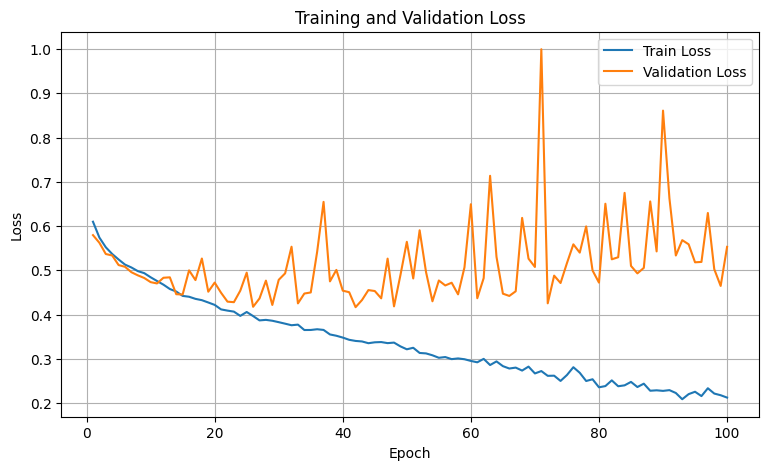

Saved: mmi711_outputs_multilabel\figures\multilabel_loss_curve.png


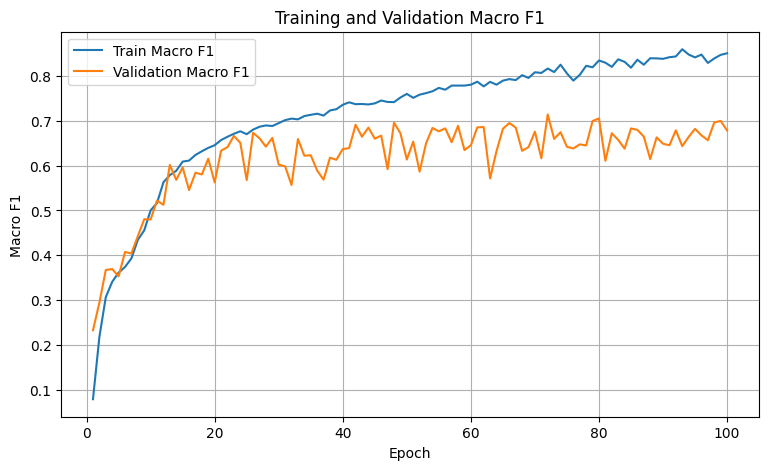

Saved: mmi711_outputs_multilabel\figures\multilabel_macro_f1_curve.png


In [11]:
plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

save_path = FIGURE_DIR / "multilabel_loss_curve.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)


plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="Train Macro F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Training and Validation Macro F1")
plt.legend()
plt.grid(True)

save_path = FIGURE_DIR / "multilabel_macro_f1_curve.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

In [12]:
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

print("Loaded best model from epoch:", checkpoint["epoch"])
print("Best validation macro F1:", checkpoint["best_val_macro_f1"])
print("Threshold:", checkpoint["threshold"])

Loaded best model from epoch: 72
Best validation macro F1: 0.7139673984733896
Threshold: 0.5


In [13]:
def get_predictions_multiple_lengths(model, loaders, threshold=0.5):
    model.eval()

    all_probs = []
    all_targets = []

    with torch.no_grad():
        for loader in loaders:
            for X_batch, Y_batch in loader:
                X_batch = X_batch.to(device)

                logits = model(X_batch)
                probs = torch.sigmoid(logits)

                all_probs.append(probs.cpu().numpy())
                all_targets.append(Y_batch.numpy())

    y_prob = np.vstack(all_probs)
    y_true = np.vstack(all_targets).astype(int)
    y_pred = apply_threshold(y_prob, threshold)

    return y_true, y_pred, y_prob


def get_eval_metadata(meta_all, dataset_name, lengths):
    frames = []

    for length in lengths:
        temp = meta_all[
            (meta_all["dataset"] == dataset_name) &
            (meta_all["length"] == length)
        ].copy()

        frames.append(temp)

    return pd.concat(frames, ignore_index=True)

In [14]:
def evaluate_multilabel_model(model, loaders, title, save_prefix, threshold=0.5):
    y_true, y_pred, y_prob = get_predictions_multiple_lengths(
        model,
        loaders,
        threshold=threshold
    )

    metrics = compute_multilabel_metrics(y_true, y_pred)

    print("\n" + title)
    print("=" * len(title))

    for key, value in metrics.items():
        print(f"{key:25s}: {value:.4f}")

    print("\nPer-label classification report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=EVENT_LABELS,
        digits=4,
        zero_division=0
    ))

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=EVENT_LABELS,
        digits=4,
        zero_division=0,
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).T
    report_df.to_csv(OUTPUT_DIR / f"{save_prefix}_classification_report.csv")

    ml_cm = multilabel_confusion_matrix(y_true, y_pred)

    rows = []
    for i, label in enumerate(EVENT_LABELS):
        tn, fp, fn, tp = ml_cm[i].ravel()
        rows.append({
            "label": label,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp
        })

    cm_df = pd.DataFrame(rows)
    cm_df.to_csv(OUTPUT_DIR / f"{save_prefix}_per_label_confusion_counts.csv", index=False)

    label_f1_scores = []
    for label in EVENT_LABELS:
        label_f1_scores.append(report_dict[label]["f1-score"])

    plt.figure(figsize=(9, 5))
    plt.bar(EVENT_LABELS, label_f1_scores)
    plt.ylim(0, 1)
    plt.ylabel("F1-score")
    plt.title(title + " - Per-label F1")
    plt.xticks(rotation=30)
    plt.grid(axis="y")

    save_path = FIGURE_DIR / f"{save_prefix}_per_label_f1.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved per-label F1 plot:", save_path)

    result_row = {
        "dataset": title
    }
    result_row.update(metrics)

    return result_row, y_true, y_pred, y_prob

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score, multilabel_confusion_matrix

def compute_classwise_multilabel_metrics(
    y_true,
    y_pred,
    label_names,
    dataset_name,
    setting,
    thresholds
):
    rows = []

    ml_cm = multilabel_confusion_matrix(y_true, y_pred)

    thresholds = np.asarray(thresholds)

    for i, label in enumerate(label_names):
        tn, fp, fn, tp = ml_cm[i].ravel()

        if thresholds.ndim == 0:
            threshold_value = float(thresholds)
        else:
            threshold_value = float(thresholds[i])

        rows.append({
            "dataset": dataset_name,
            "setting": setting,
            "label": label,
            "threshold": threshold_value,
            "precision": precision_score(y_true[:, i], y_pred[:, i], zero_division=0),
            "recall": recall_score(y_true[:, i], y_pred[:, i], zero_division=0),
            "f1": f1_score(y_true[:, i], y_pred[:, i], zero_division=0),
            "support": int(y_true[:, i].sum()),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp)
        })

    return pd.DataFrame(rows)

In [31]:
from sklearn.metrics import f1_score, precision_score, recall_score

def tune_multilabel_thresholds_per_class(
    y_true,
    y_prob,
    label_names,
    thresholds=None
):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.01)

    rows = []
    best_thresholds = []

    for class_idx, label in enumerate(label_names):
        best_threshold = 0.5
        best_f1 = -1
        best_precision = 0
        best_recall = 0

        for threshold in thresholds:
            y_pred_class = (y_prob[:, class_idx] >= threshold).astype(int)

            precision = precision_score(
                y_true[:, class_idx],
                y_pred_class,
                zero_division=0
            )

            recall = recall_score(
                y_true[:, class_idx],
                y_pred_class,
                zero_division=0
            )

            f1 = f1_score(
                y_true[:, class_idx],
                y_pred_class,
                zero_division=0
            )

            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold
                best_precision = precision
                best_recall = recall

        best_thresholds.append(best_threshold)

        rows.append({
            "label": label,
            "best_threshold": best_threshold,
            "validation_precision": best_precision,
            "validation_recall": best_recall,
            "validation_f1": best_f1
        })

    threshold_df = pd.DataFrame(rows)

    return np.array(best_thresholds), threshold_df

In [32]:
y_true_val_for_tuning, y_pred_val_default, y_prob_val_for_tuning = get_predictions_multiple_lengths(
    model,
    val_loaders,
    threshold=0.5
)

TUNED_CLASS_THRESHOLDS, class_threshold_df = tune_multilabel_thresholds_per_class(
    y_true=y_true_val_for_tuning,
    y_prob=y_prob_val_for_tuning,
    label_names=EVENT_LABELS,
    thresholds=np.arange(0.05, 0.96, 0.01)
)

class_threshold_df.to_csv(
    OUTPUT_DIR / "validation_threshold_tuning_multilabel.csv",
    index=False
)

class_threshold_df

,label,best_threshold,validation_precision,validation_recall,validation_f1
0,mean_shift,0.39,0.690196,0.782222,0.733333
1,variance_shift,0.65,0.830000,0.737778,0.781176
2,trend_shift,0.40,0.719577,0.604444,0.657005
3,point_anomaly,0.49,0.641667,0.684444,0.662366
4,collective_anomaly,0.40,0.871795,0.755556,0.809524



Validation Set: In-Distribution
exact_match_accuracy     : 0.4056
macro_precision          : 0.7576
macro_recall             : 0.6827
macro_f1                 : 0.7140
micro_precision          : 0.7500
micro_recall             : 0.6827
micro_f1                 : 0.7148
samples_f1               : 0.6700
hamming_loss             : 0.1703
no_event_accuracy        : 0.2667

Per-label classification report:
                    precision    recall  f1-score   support

        mean_shift     0.7488    0.6756    0.7103       225
    variance_shift     0.7427    0.7956    0.7682       225
       trend_shift     0.7640    0.5467    0.6373       225
     point_anomaly     0.6429    0.6800    0.6609       225
collective_anomaly     0.8895    0.7156    0.7931       225

         micro avg     0.7500    0.6827    0.7148      1125
         macro avg     0.7576    0.6827    0.7140      1125
      weighted avg     0.7576    0.6827    0.7140      1125
       samples avg     0.7324    0.6646    0.6700  

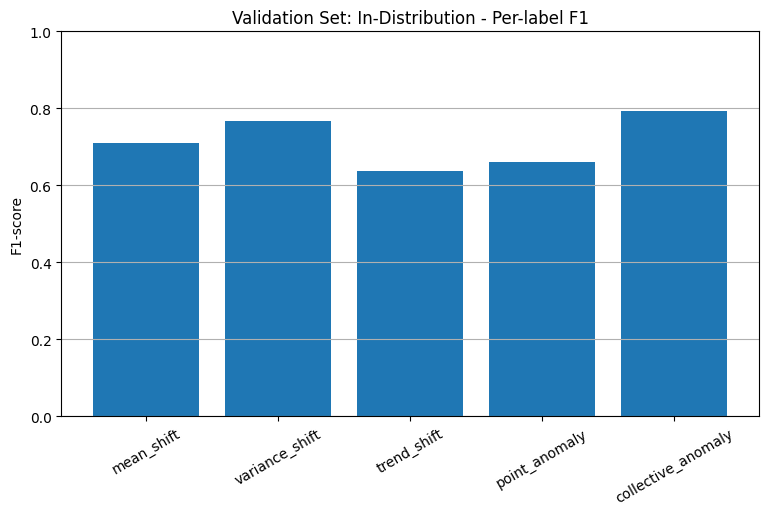

Saved per-label F1 plot: mmi711_outputs_multilabel\figures\validation_default_per_label_f1.png

OOD Test A: Shifted Event Parameters
exact_match_accuracy     : 0.2722
macro_precision          : 0.6493
macro_recall             : 0.5662
macro_f1                 : 0.6019
micro_precision          : 0.6622
micro_recall             : 0.5662
micro_f1                 : 0.6104
samples_f1               : 0.5535
hamming_loss             : 0.2258
no_event_accuracy        : 0.1333

Per-label classification report:
                    precision    recall  f1-score   support

        mean_shift     0.6480    0.5644    0.6033       225
    variance_shift     0.5833    0.4978    0.5372       225
       trend_shift     0.5655    0.3644    0.4432       225
     point_anomaly     0.5248    0.4711    0.4965       225
collective_anomaly     0.9251    0.9333    0.9292       225

         micro avg     0.6622    0.5662    0.6104      1125
         macro avg     0.6493    0.5662    0.6019      1125
      weigh

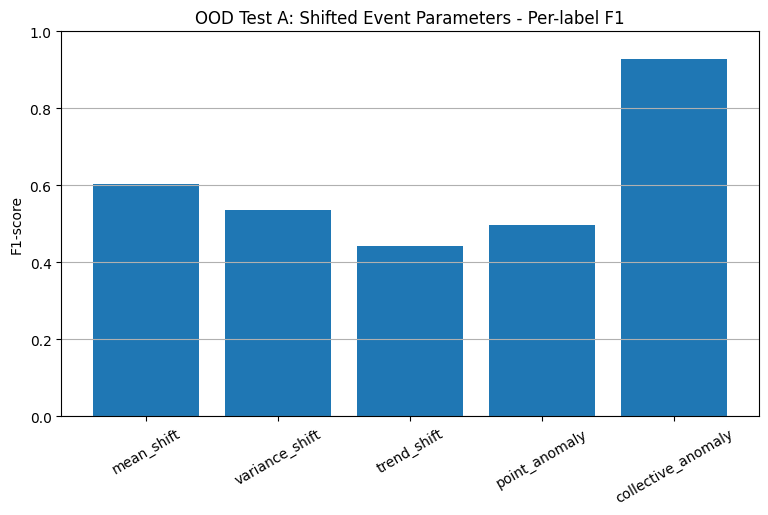

Saved per-label F1 plot: mmi711_outputs_multilabel\figures\ood_params_default_per_label_f1.png

OOD Test B: Harder Backgrounds
exact_match_accuracy     : 0.2306
macro_precision          : 0.5989
macro_recall             : 0.5689
macro_f1                 : 0.5795
micro_precision          : 0.5866
micro_recall             : 0.5689
micro_f1                 : 0.5776
samples_f1               : 0.5355
hamming_loss             : 0.2600
no_event_accuracy        : 0.1556

Per-label classification report:
                    precision    recall  f1-score   support

        mean_shift     0.4747    0.5422    0.5062       225
    variance_shift     0.5000    0.4667    0.4828       225
       trend_shift     0.5429    0.5067    0.5241       225
     point_anomaly     0.6586    0.7289    0.6920       225
collective_anomaly     0.8182    0.6000    0.6923       225

         micro avg     0.5866    0.5689    0.5776      1125
         macro avg     0.5989    0.5689    0.5795      1125
      weighted av

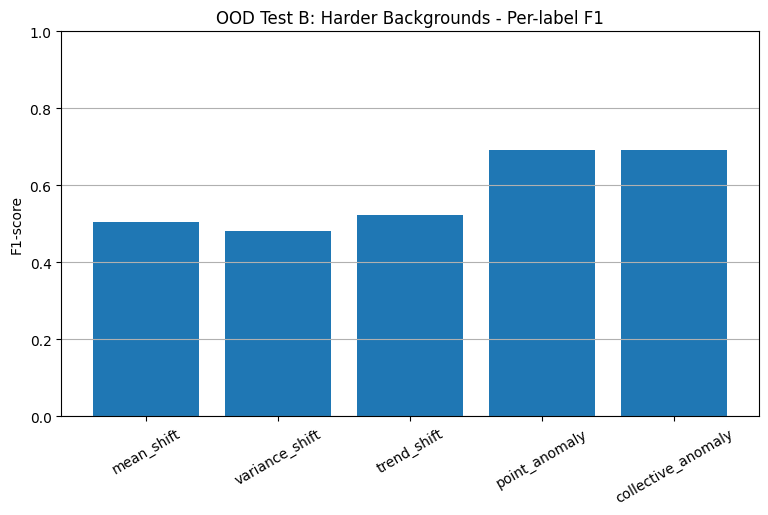

Saved per-label F1 plot: mmi711_outputs_multilabel\figures\ood_background_default_per_label_f1.png


,dataset,exact_match_accuracy,macro_precision,macro_recall,macro_f1,micro_precision,micro_recall,micro_f1,samples_f1,hamming_loss,no_event_accuracy
0,Validation Set: In-Distribution,0.405556,0.757568,0.682667,0.713967,0.750000,0.682667,0.714751,0.669954,0.170278,0.266667
1,OOD Test A: Shifted Event Parameters,0.272222,0.649334,0.566222,0.601886,0.662162,0.566222,0.610446,0.553472,0.225833,0.133333
2,OOD Test B: Harder Backgrounds,0.230556,0.598876,0.568889,0.579482,0.586618,0.568889,0.577617,0.535463,0.260000,0.155556


,dataset,setting,label,threshold,precision,recall,f1,support,tn,fp,fn,tp
0,validation,default_0.5,mean_shift,0.5,0.748768,0.675556,0.710280,225,444,51,73,152
1,validation,default_0.5,variance_shift,0.5,0.742739,0.795556,0.768240,225,433,62,46,179
2,validation,default_0.5,trend_shift,0.5,0.763975,0.546667,0.637306,225,457,38,102,123
3,validation,default_0.5,point_anomaly,0.5,0.642857,0.680000,0.660907,225,410,85,72,153
4,validation,default_0.5,collective_anomaly,0.5,0.889503,0.715556,0.793103,225,475,20,64,161
5,ood_params,default_0.5,mean_shift,0.5,0.647959,0.564444,0.603325,225,426,69,98,127
6,ood_params,default_0.5,variance_shift,0.5,0.583333,0.497778,0.537170,225,415,80,113,112
7,ood_params,default_0.5,trend_shift,0.5,0.565517,0.364444,0.443243,225,432,63,143,82
8,ood_params,default_0.5,point_anomaly,0.5,0.524752,0.471111,0.496487,225,399,96,119,106
9,ood_params,default_0.5,collective_anomaly,0.5,0.925110,0.933333,0.929204,225,478,17,15,210


In [36]:
results_default = []
classwise_default = []

val_result_default, y_true_val_default, y_pred_val_default, y_prob_val_default = evaluate_multilabel_model(
    model,
    val_loaders,
    "Validation Set: In-Distribution",
    "validation_default",
    threshold=0.5
)
results_default.append(val_result_default)

classwise_default.append(
    compute_classwise_multilabel_metrics(
        y_true=y_true_val_default,
        y_pred=y_pred_val_default,
        label_names=EVENT_LABELS,
        dataset_name="validation",
        setting="default_0.5",
        thresholds=0.5
    )
)

ood_params_result_default, y_true_ood_params_default, y_pred_ood_params_default, y_prob_ood_params_default = evaluate_multilabel_model(
    model,
    ood_params_loaders,
    "OOD Test A: Shifted Event Parameters",
    "ood_params_default",
    threshold=0.5
)
results_default.append(ood_params_result_default)

classwise_default.append(
    compute_classwise_multilabel_metrics(
        y_true=y_true_ood_params_default,
        y_pred=y_pred_ood_params_default,
        label_names=EVENT_LABELS,
        dataset_name="ood_params",
        setting="default_0.5",
        thresholds=0.5
    )
)

ood_background_result_default, y_true_ood_background_default, y_pred_ood_background_default, y_prob_ood_background_default = evaluate_multilabel_model(
    model,
    ood_background_loaders,
    "OOD Test B: Harder Backgrounds",
    "ood_background_default",
    threshold=0.5
)
results_default.append(ood_background_result_default)

classwise_default.append(
    compute_classwise_multilabel_metrics(
        y_true=y_true_ood_background_default,
        y_pred=y_pred_ood_background_default,
        label_names=EVENT_LABELS,
        dataset_name="ood_background",
        setting="default_0.5",
        thresholds=0.5
    )
)

results_df_default = pd.DataFrame(results_default)

results_df_default.to_csv(
    OUTPUT_DIR / "final_results_summary_multilabel_default_threshold.csv",
    index=False
)

classwise_df_default = pd.concat(classwise_default, ignore_index=True)

classwise_df_default.to_csv(
    OUTPUT_DIR / "classwise_results_multilabel_default_threshold.csv",
    index=False
)

display(results_df_default)
display(classwise_df_default)


Validation Set: In-Distribution
exact_match_accuracy     : 0.4111
macro_precision          : 0.7506
macro_recall             : 0.7129
macro_f1                 : 0.7287
micro_precision          : 0.7433
micro_recall             : 0.7129
micro_f1                 : 0.7278
samples_f1               : 0.6815
hamming_loss             : 0.1667
no_event_accuracy        : 0.2444

Per-label classification report:
                    precision    recall  f1-score   support

        mean_shift     0.6902    0.7822    0.7333       225
    variance_shift     0.8300    0.7378    0.7812       225
       trend_shift     0.7196    0.6044    0.6570       225
     point_anomaly     0.6417    0.6844    0.6624       225
collective_anomaly     0.8718    0.7556    0.8095       225

         micro avg     0.7433    0.7129    0.7278      1125
         macro avg     0.7506    0.7129    0.7287      1125
      weighted avg     0.7506    0.7129    0.7287      1125
       samples avg     0.7289    0.6903    0.6815  

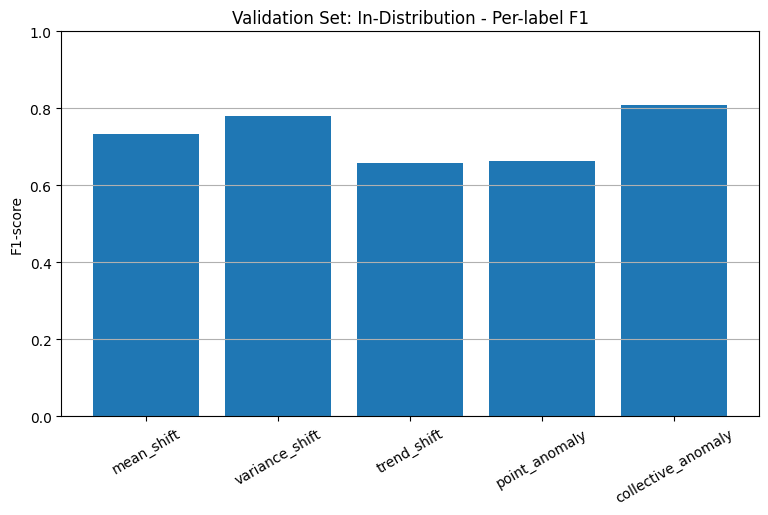

Saved per-label F1 plot: mmi711_outputs_multilabel\figures\validation_tuned_per_label_f1.png

OOD Test A: Shifted Event Parameters
exact_match_accuracy     : 0.2778
macro_precision          : 0.6385
macro_recall             : 0.5964
macro_f1                 : 0.6121
micro_precision          : 0.6471
micro_recall             : 0.5964
micro_f1                 : 0.6207
samples_f1               : 0.5706
hamming_loss             : 0.2278
no_event_accuracy        : 0.2000

Per-label classification report:
                    precision    recall  f1-score   support

        mean_shift     0.5892    0.6311    0.6094       225
    variance_shift     0.6536    0.4444    0.5291       225
       trend_shift     0.5469    0.4667    0.5036       225
     point_anomaly     0.5245    0.4756    0.4988       225
collective_anomaly     0.8785    0.9644    0.9195       225

         micro avg     0.6471    0.5964    0.6207      1125
         macro avg     0.6385    0.5964    0.6121      1125
      weighte

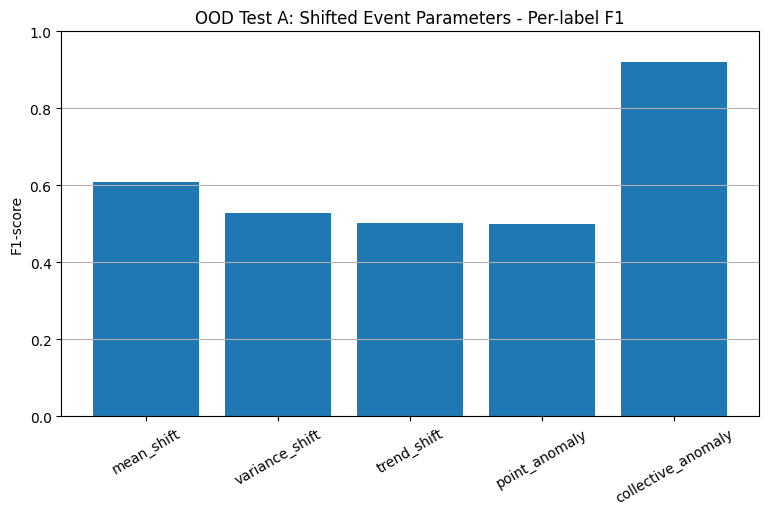

Saved per-label F1 plot: mmi711_outputs_multilabel\figures\ood_params_tuned_per_label_f1.png

OOD Test B: Harder Backgrounds
exact_match_accuracy     : 0.2250
macro_precision          : 0.5779
macro_recall             : 0.6027
macro_f1                 : 0.5817
micro_precision          : 0.5645
micro_recall             : 0.6027
micro_f1                 : 0.5830
samples_f1               : 0.5507
hamming_loss             : 0.2694
no_event_accuracy        : 0.1111

Per-label classification report:
                    precision    recall  f1-score   support

        mean_shift     0.4500    0.6400    0.5284       225
    variance_shift     0.5592    0.3778    0.4509       225
       trend_shift     0.4890    0.5911    0.5352       225
     point_anomaly     0.6561    0.7378    0.6946       225
collective_anomaly     0.7353    0.6667    0.6993       225

         micro avg     0.5645    0.6027    0.5830      1125
         macro avg     0.5779    0.6027    0.5817      1125
      weighted avg 

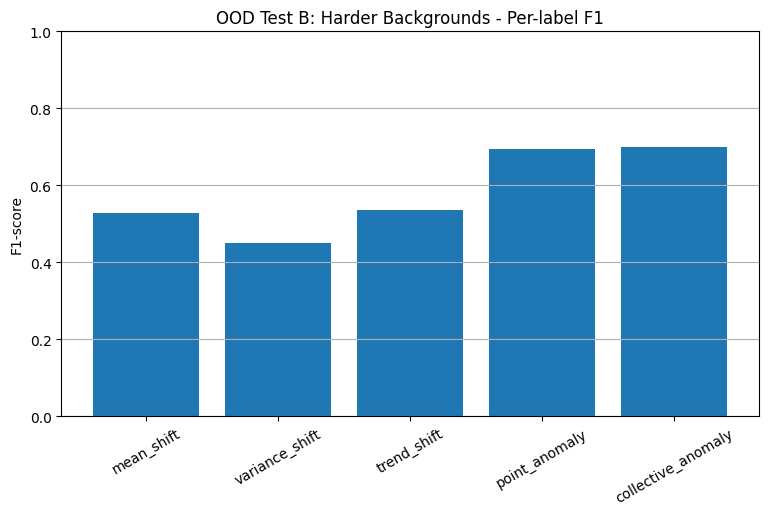

Saved per-label F1 plot: mmi711_outputs_multilabel\figures\ood_background_tuned_per_label_f1.png


,dataset,exact_match_accuracy,macro_precision,macro_recall,macro_f1,micro_precision,micro_recall,micro_f1,samples_f1,hamming_loss,no_event_accuracy
0,Validation Set: In-Distribution,0.411111,0.750647,0.712889,0.728681,0.743281,0.712889,0.727768,0.681481,0.166667,0.244444
1,OOD Test A: Shifted Event Parameters,0.277778,0.638547,0.596444,0.612093,0.647059,0.596444,0.620722,0.570556,0.227778,0.200000
2,OOD Test B: Harder Backgrounds,0.225000,0.577920,0.602667,0.581688,0.564530,0.602667,0.582975,0.550741,0.269444,0.111111


,dataset,setting,label,threshold,precision,recall,f1,support,tn,fp,fn,tp
0,validation,tuned,mean_shift,0.39,0.690196,0.782222,0.733333,225,416,79,49,176
1,validation,tuned,variance_shift,0.65,0.830000,0.737778,0.781176,225,461,34,59,166
2,validation,tuned,trend_shift,0.40,0.719577,0.604444,0.657005,225,442,53,89,136
3,validation,tuned,point_anomaly,0.49,0.641667,0.684444,0.662366,225,409,86,71,154
4,validation,tuned,collective_anomaly,0.40,0.871795,0.755556,0.809524,225,470,25,55,170
5,ood_params,tuned,mean_shift,0.39,0.589212,0.631111,0.609442,225,396,99,83,142
6,ood_params,tuned,variance_shift,0.65,0.653595,0.444444,0.529101,225,442,53,125,100
7,ood_params,tuned,trend_shift,0.40,0.546875,0.466667,0.503597,225,408,87,120,105
8,ood_params,tuned,point_anomaly,0.49,0.524510,0.475556,0.498834,225,398,97,118,107
9,ood_params,tuned,collective_anomaly,0.40,0.878543,0.964444,0.919492,225,465,30,8,217


In [35]:
results_tuned = []
classwise_tuned = []

val_result_tuned, y_true_val_tuned, y_pred_val_tuned, y_prob_val_tuned = evaluate_multilabel_model(
    model,
    val_loaders,
    "Validation Set: In-Distribution",
    "validation_tuned",
    threshold=TUNED_CLASS_THRESHOLDS
)
results_tuned.append(val_result_tuned)

classwise_tuned.append(
    compute_classwise_multilabel_metrics(
        y_true=y_true_val_tuned,
        y_pred=y_pred_val_tuned,
        label_names=EVENT_LABELS,
        dataset_name="validation",
        setting="tuned",
        thresholds=TUNED_CLASS_THRESHOLDS
    )
)

ood_params_result_tuned, y_true_ood_params_tuned, y_pred_ood_params_tuned, y_prob_ood_params_tuned = evaluate_multilabel_model(
    model,
    ood_params_loaders,
    "OOD Test A: Shifted Event Parameters",
    "ood_params_tuned",
    threshold=TUNED_CLASS_THRESHOLDS
)
results_tuned.append(ood_params_result_tuned)

classwise_tuned.append(
    compute_classwise_multilabel_metrics(
        y_true=y_true_ood_params_tuned,
        y_pred=y_pred_ood_params_tuned,
        label_names=EVENT_LABELS,
        dataset_name="ood_params",
        setting="tuned",
        thresholds=TUNED_CLASS_THRESHOLDS
    )
)

ood_background_result_tuned, y_true_ood_background_tuned, y_pred_ood_background_tuned, y_prob_ood_background_tuned = evaluate_multilabel_model(
    model,
    ood_background_loaders,
    "OOD Test B: Harder Backgrounds",
    "ood_background_tuned",
    threshold=TUNED_CLASS_THRESHOLDS
)
results_tuned.append(ood_background_result_tuned)

classwise_tuned.append(
    compute_classwise_multilabel_metrics(
        y_true=y_true_ood_background_tuned,
        y_pred=y_pred_ood_background_tuned,
        label_names=EVENT_LABELS,
        dataset_name="ood_background",
        setting="tuned",
        thresholds=TUNED_CLASS_THRESHOLDS
    )
)

results_df_tuned = pd.DataFrame(results_tuned)

results_df_tuned.to_csv(
    OUTPUT_DIR / "final_results_summary_multilabel_tuned_threshold.csv",
    index=False
)

classwise_df_tuned = pd.concat(classwise_tuned, ignore_index=True)

classwise_df_tuned.to_csv(
    OUTPUT_DIR / "classwise_results_multilabel_tuned_threshold.csv",
    index=False
)

display(results_df_tuned)
display(classwise_df_tuned)

In [37]:
# Add setting labels
results_default_compare = results_df_default.copy()
results_default_compare["setting"] = "default_0.5"

results_tuned_compare = results_df_tuned.copy()
results_tuned_compare["setting"] = "tuned"

# Combine default and tuned summary results
overall_threshold_comparison_long = pd.concat(
    [results_default_compare, results_tuned_compare],
    ignore_index=True
)

overall_threshold_comparison_long.to_csv(
    OUTPUT_DIR / "overall_default_vs_tuned_threshold_long.csv",
    index=False
)

overall_threshold_comparison_long

,dataset,exact_match_accuracy,macro_precision,macro_recall,macro_f1,micro_precision,micro_recall,micro_f1,samples_f1,hamming_loss,no_event_accuracy,setting
0,Validation Set: In-Distribution,0.405556,0.757568,0.682667,0.713967,0.750000,0.682667,0.714751,0.669954,0.170278,0.266667,default_0.5
1,OOD Test A: Shifted Event Parameters,0.272222,0.649334,0.566222,0.601886,0.662162,0.566222,0.610446,0.553472,0.225833,0.133333,default_0.5
2,OOD Test B: Harder Backgrounds,0.230556,0.598876,0.568889,0.579482,0.586618,0.568889,0.577617,0.535463,0.260000,0.155556,default_0.5
3,Validation Set: In-Distribution,0.411111,0.750647,0.712889,0.728681,0.743281,0.712889,0.727768,0.681481,0.166667,0.244444,tuned
4,OOD Test A: Shifted Event Parameters,0.277778,0.638547,0.596444,0.612093,0.647059,0.596444,0.620722,0.570556,0.227778,0.200000,tuned
5,OOD Test B: Harder Backgrounds,0.225000,0.577920,0.602667,0.581688,0.564530,0.602667,0.582975,0.550741,0.269444,0.111111,tuned


In [38]:
# Merge default and tuned results side by side
overall_threshold_comparison_wide = results_df_default.merge(
    results_df_tuned,
    on="dataset",
    suffixes=("_default", "_tuned")
)

# Compute changes for numeric metric columns
for col in results_df_default.columns:
    if col == "dataset":
        continue

    if pd.api.types.is_numeric_dtype(results_df_default[col]):
        overall_threshold_comparison_wide[f"{col}_change"] = (
            overall_threshold_comparison_wide[f"{col}_tuned"] -
            overall_threshold_comparison_wide[f"{col}_default"]
        )

overall_threshold_comparison_wide.to_csv(
    OUTPUT_DIR / "overall_default_vs_tuned_threshold_comparison.csv",
    index=False
)

overall_threshold_comparison_wide

,dataset,exact_match_accuracy_default,macro_precision_default,macro_recall_default,macro_f1_default,micro_precision_default,micro_recall_default,micro_f1_default,samples_f1_default,hamming_loss_default,...,exact_match_accuracy_change,macro_precision_change,macro_recall_change,macro_f1_change,micro_precision_change,micro_recall_change,micro_f1_change,samples_f1_change,hamming_loss_change,no_event_accuracy_change
0,Validation Set: In-Distribution,0.405556,0.757568,0.682667,0.713967,0.750000,0.682667,0.714751,0.669954,0.170278,...,0.005556,-0.006922,0.030222,0.014713,-0.006719,0.030222,0.013017,0.011528,-0.003611,-0.022222
1,OOD Test A: Shifted Event Parameters,0.272222,0.649334,0.566222,0.601886,0.662162,0.566222,0.610446,0.553472,0.225833,...,0.005556,-0.010788,0.030222,0.010207,-0.015103,0.030222,0.010276,0.017083,0.001944,0.066667
2,OOD Test B: Harder Backgrounds,0.230556,0.598876,0.568889,0.579482,0.586618,0.568889,0.577617,0.535463,0.260000,...,-0.005556,-0.020956,0.033778,0.002206,-0.022088,0.033778,0.005358,0.015278,0.009444,-0.044444


In [39]:
classwise_threshold_comparison_long = pd.concat(
    [classwise_df_default, classwise_df_tuned],
    ignore_index=True
)

classwise_threshold_comparison_long.to_csv(
    OUTPUT_DIR / "classwise_default_vs_tuned_threshold_long.csv",
    index=False
)

classwise_threshold_comparison_long

,dataset,setting,label,threshold,precision,recall,f1,support,tn,fp,fn,tp
0,validation,default_0.5,mean_shift,0.50,0.748768,0.675556,0.710280,225,444,51,73,152
1,validation,default_0.5,variance_shift,0.50,0.742739,0.795556,0.768240,225,433,62,46,179
2,validation,default_0.5,trend_shift,0.50,0.763975,0.546667,0.637306,225,457,38,102,123
3,validation,default_0.5,point_anomaly,0.50,0.642857,0.680000,0.660907,225,410,85,72,153
4,validation,default_0.5,collective_anomaly,0.50,0.889503,0.715556,0.793103,225,475,20,64,161
5,ood_params,default_0.5,mean_shift,0.50,0.647959,0.564444,0.603325,225,426,69,98,127
6,ood_params,default_0.5,variance_shift,0.50,0.583333,0.497778,0.537170,225,415,80,113,112
7,ood_params,default_0.5,trend_shift,0.50,0.565517,0.364444,0.443243,225,432,63,143,82
8,ood_params,default_0.5,point_anomaly,0.50,0.524752,0.471111,0.496487,225,399,96,119,106
9,ood_params,default_0.5,collective_anomaly,0.50,0.925110,0.933333,0.929204,225,478,17,15,210


In [40]:
classwise_threshold_comparison_wide = classwise_df_default.merge(
    classwise_df_tuned,
    on=["dataset", "label"],
    suffixes=("_default", "_tuned")
)

# Changes in main metrics
for metric in ["precision", "recall", "f1", "fp", "fn", "tp", "tn"]:
    classwise_threshold_comparison_wide[f"{metric}_change"] = (
        classwise_threshold_comparison_wide[f"{metric}_tuned"] -
        classwise_threshold_comparison_wide[f"{metric}_default"]
    )

classwise_threshold_comparison_wide.to_csv(
    OUTPUT_DIR / "classwise_default_vs_tuned_threshold_comparison.csv",
    index=False
)

classwise_threshold_comparison_wide

,dataset,setting_default,label,threshold_default,precision_default,recall_default,f1_default,support_default,tn_default,fp_default,...,fp_tuned,fn_tuned,tp_tuned,precision_change,recall_change,f1_change,fp_change,fn_change,tp_change,tn_change
0,validation,default_0.5,mean_shift,0.5,0.748768,0.675556,0.710280,225,444,51,...,79,49,176,-0.058572,0.106667,0.023053,28,-24,24,-28
1,validation,default_0.5,variance_shift,0.5,0.742739,0.795556,0.768240,225,433,62,...,34,59,166,0.087261,-0.057778,0.012936,-28,13,-13,28
2,validation,default_0.5,trend_shift,0.5,0.763975,0.546667,0.637306,225,457,38,...,53,89,136,-0.044398,0.057778,0.019699,15,-13,13,-15
3,validation,default_0.5,point_anomaly,0.5,0.642857,0.680000,0.660907,225,410,85,...,86,71,154,-0.001190,0.004444,0.001458,1,-1,1,-1
4,validation,default_0.5,collective_anomaly,0.5,0.889503,0.715556,0.793103,225,475,20,...,25,55,170,-0.017708,0.040000,0.016420,5,-9,9,-5
5,ood_params,default_0.5,mean_shift,0.5,0.647959,0.564444,0.603325,225,426,69,...,99,83,142,-0.058748,0.066667,0.006117,30,-15,15,-30
6,ood_params,default_0.5,variance_shift,0.5,0.583333,0.497778,0.537170,225,415,80,...,53,125,100,0.070261,-0.053333,-0.008070,-27,12,-12,27
7,ood_params,default_0.5,trend_shift,0.5,0.565517,0.364444,0.443243,225,432,63,...,87,120,105,-0.018642,0.102222,0.060354,24,-23,23,-24
8,ood_params,default_0.5,point_anomaly,0.5,0.524752,0.471111,0.496487,225,399,96,...,97,118,107,-0.000243,0.004444,0.002347,1,-1,1,-1
9,ood_params,default_0.5,collective_anomaly,0.5,0.925110,0.933333,0.929204,225,478,17,...,30,8,217,-0.046568,0.031111,-0.009712,13,-7,7,-13


In [41]:
classwise_threshold_comparison_summary = classwise_threshold_comparison_wide[
    [
        "dataset",
        "label",

        "threshold_default",
        "threshold_tuned",

        "precision_default",
        "precision_tuned",
        "precision_change",

        "recall_default",
        "recall_tuned",
        "recall_change",

        "f1_default",
        "f1_tuned",
        "f1_change",

        "fp_default",
        "fp_tuned",
        "fp_change",

        "fn_default",
        "fn_tuned",
        "fn_change"
    ]
]

classwise_threshold_comparison_summary.to_csv(
    OUTPUT_DIR / "classwise_default_vs_tuned_threshold_summary.csv",
    index=False
)

classwise_threshold_comparison_summary

,dataset,label,threshold_default,threshold_tuned,precision_default,precision_tuned,precision_change,recall_default,recall_tuned,recall_change,f1_default,f1_tuned,f1_change,fp_default,fp_tuned,fp_change,fn_default,fn_tuned,fn_change
0,validation,mean_shift,0.5,0.39,0.748768,0.690196,-0.058572,0.675556,0.782222,0.106667,0.710280,0.733333,0.023053,51,79,28,73,49,-24
1,validation,variance_shift,0.5,0.65,0.742739,0.830000,0.087261,0.795556,0.737778,-0.057778,0.768240,0.781176,0.012936,62,34,-28,46,59,13
2,validation,trend_shift,0.5,0.40,0.763975,0.719577,-0.044398,0.546667,0.604444,0.057778,0.637306,0.657005,0.019699,38,53,15,102,89,-13
3,validation,point_anomaly,0.5,0.49,0.642857,0.641667,-0.001190,0.680000,0.684444,0.004444,0.660907,0.662366,0.001458,85,86,1,72,71,-1
4,validation,collective_anomaly,0.5,0.40,0.889503,0.871795,-0.017708,0.715556,0.755556,0.040000,0.793103,0.809524,0.016420,20,25,5,64,55,-9
5,ood_params,mean_shift,0.5,0.39,0.647959,0.589212,-0.058748,0.564444,0.631111,0.066667,0.603325,0.609442,0.006117,69,99,30,98,83,-15
6,ood_params,variance_shift,0.5,0.65,0.583333,0.653595,0.070261,0.497778,0.444444,-0.053333,0.537170,0.529101,-0.008070,80,53,-27,113,125,12
7,ood_params,trend_shift,0.5,0.40,0.565517,0.546875,-0.018642,0.364444,0.466667,0.102222,0.443243,0.503597,0.060354,63,87,24,143,120,-23
8,ood_params,point_anomaly,0.5,0.49,0.524752,0.524510,-0.000243,0.471111,0.475556,0.004444,0.496487,0.498834,0.002347,96,97,1,119,118,-1
9,ood_params,collective_anomaly,0.5,0.40,0.925110,0.878543,-0.046568,0.933333,0.964444,0.031111,0.929204,0.919492,-0.009712,17,30,13,15,8,-7
